In [1]:
# use extension to auto reload modules
%load_ext autoreload
%autoreload 2
# %load_ext line_profiler

In [2]:
import logging
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.pandas
import seaborn as sns
import numpy as np
import scipy
import scipy.stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


Before engineering or selecting features, building models etc., let have a look at the data involved in this project. 
As explained in the data-retrieval part, some dependencies between the daily bike counts and other exogeneous variables are suspected.
Accordingly, this notebook explores these dependencies in more or less complex manners.

# Simple dataviz

First, the static data scrapped from eco-counter and fetched from the web are retrieved.

In [3]:
# find all the parquet files ending by "_bike_counts_with_weather.parquet" in the data/ folder
# load them and put the resulting table in a dict where the key is the prefix of the file name
data_folder = "data/"
data_counters = {}
for file_name in os.listdir(data_folder):
    if file_name.endswith("_bike_counts_with_weather.parquet"):
        nickname_clean = file_name.replace("_bike_counts_with_weather.parquet", "")
        data_counters[nickname_clean] = pd.read_parquet(os.path.join(data_folder, file_name))

Gathering all data from all counters is created, with a new column denoting the counter nickname.

In [4]:
# regroup all dataframes in the data_counters dict in a single dataframe with an additional column "counter" that contains the nickname of the counter
data_all_counters = pd.concat(
    [df.assign(counter=nickname) for nickname, df in data_counters.items()],
).sort_index().loc["2021":,:] # drop 2020 data because of covid
data_all_counters

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations,counter
date,,,,,,,,,,,,,,,,,,,
2021-01-01,6.9,5.5,9.3,11.2,<NA>,<NA>,19.1,55.0,1006.0,<NA>,166.0,95.0,71.0,True,False,Friday,True,True,nice_carras
2021-01-01,2.2,0.6,4.1,0.2,1.0,<NA>,7.6,18.5,1010.8,<NA>,2037.0,895.0,1142.0,False,False,Friday,True,True,paris_sebastopol
2021-01-02,7.4,5.8,11.2,23.9,<NA>,<NA>,18.7,50.0,1001.4,<NA>,349.0,206.0,143.0,True,True,Saturday,False,True,nice_carras
2021-01-02,2.2,-0.3,4.6,0.0,<NA>,<NA>,5.3,21.0,1014.9,<NA>,3987.0,1793.0,2194.0,False,True,Saturday,False,True,paris_sebastopol
2021-01-03,3.4,2.8,4.3,0.0,<NA>,<NA>,8.6,31.0,1014.2,<NA>,3306.0,1386.0,1920.0,False,True,Sunday,False,True,paris_sebastopol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-08,7.7,5.7,9.9,0.0,<NA>,<NA>,6.2,20.4,1006.9,106.0,11666.0,4712.0,6954.0,False,True,Sunday,False,False,paris_sebastopol
2026-02-08,9.6,7.4,11.1,15.6,<NA>,<NA>,18.5,38.9,1006.8,31.0,617.0,297.0,320.0,True,True,Sunday,False,False,cagnes_sur_mer
2026-02-09,6.9,4.4,9.5,0.0,<NA>,<NA>,7.9,16.7,1006.1,156.0,14222.0,5816.0,8406.0,False,False,Monday,False,False,paris_sebastopol


In [5]:
data_paris = data_counters["paris_sebastopol"]
data_paris.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations
date,,,,,,,,,,,,,,,,,,
2020-02-10,10.9,8.0,14.2,4.8,<NA>,<NA>,28.1,93.0,1007.5,<NA>,4338,1657,2681.0,True,False,Monday,False,True
2020-02-11,6.6,4.6,9.5,0.4,<NA>,<NA>,19.4,68.0,1015.7,<NA>,6459,2612,3847.0,False,False,Tuesday,False,True
2020-02-12,6.5,4.2,9.7,0.0,<NA>,<NA>,12.9,50.0,1020.5,<NA>,7624,3053,4571.0,False,False,Wednesday,False,True
2020-02-13,8.7,5.2,12.8,2.4,<NA>,<NA>,19.2,72.2,1007.2,<NA>,6125,2498,3627.0,True,False,Thursday,False,True
2020-02-14,9.9,8.9,11.9,0.0,<NA>,<NA>,11.6,44.5,1021.6,<NA>,7327,3059,4268.0,False,False,Friday,False,True


In this first interactive plot, one can get a feeling of the variations of the bike count over time for each site. 
The mean day temperature is plotted as well to get a first feeling of seasons and how they can be related to the bike count depending on the site.

In [6]:
count_plot = data_all_counters.hvplot.line(
    y="count",
    width=900,
    height=400,
    title="Bike counts over time at a counter",
    ylabel="Bike counts",
    groupby="counter",
    hover_cols=['prcp', 'weekday','is_holiday', 'is_vacations', 'tavg'],
    )
count_plot
temp_plot = data_all_counters.hvplot.line(
    y="tavg",
    yaxis="right",
    color="firebrick",
    ylabel="Avg temperature (C)",
    groupby="counter",
    line_dash='dashed',
    hover_cols=['tavg', 'tmin', 'tmax', 'count']
    )
(count_plot * temp_plot).opts(multi_y=True)

BokehModel(combine_events=True, render_bundle={'docs_json': {'a80335e0-39e2-4911-b45e-0bcc8dd2b755': {'version…

From this first plot, one can already see some common features and differences between these three sites :
- all of them seem to have a certain yearly (weekly when zooming?) seasonlity;
- the bike count seems correlated with the external temperature;
- but the time in the year also seem to have an effect. E. g. in Paris, the evolution of the count in summer seems much different that the one in Nice.

# Seasonality and effect of the day of week

Plotting the autocorrelation of the bike-count timeseries is a first way to grab an idea of the importance of the seasonality in the data.

## ACF plot

In Paris Sebastopol, a major commuting cycleway, the data shows an expected autocorrelation with the previous day, as well as with the same day of the previous week (lag 7).
Yealrly seasonality can be guessed as well.

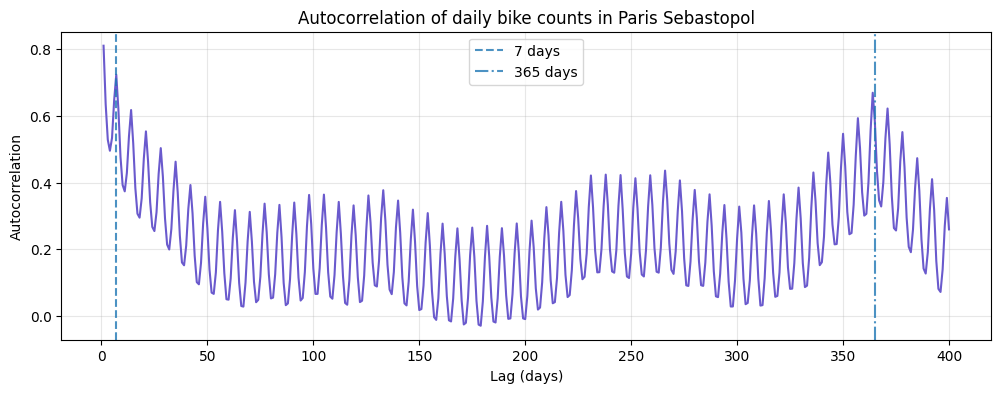

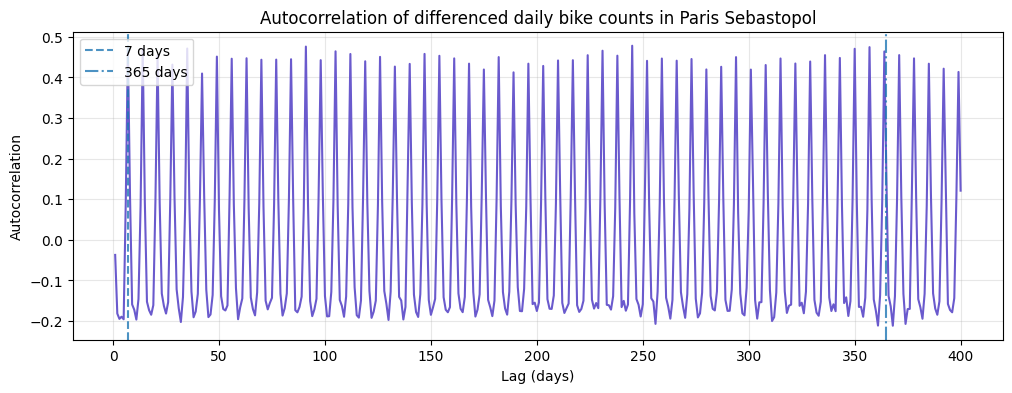

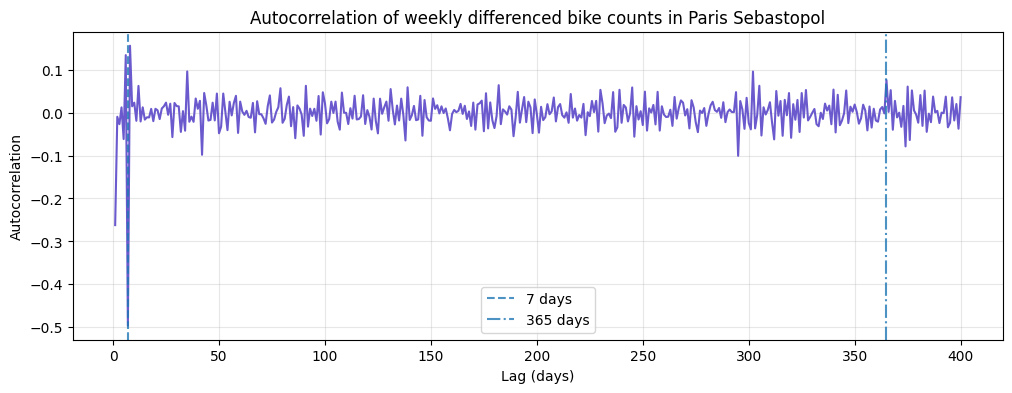

In [7]:
def plot_acf(series, max_lag=400, title="Autocorrelation", mark_lags=(7, 365)):
    series = series.dropna()
    acf_vals = [series.autocorr(lag) for lag in range(1, max_lag + 1)]
    plt.figure(figsize=(12, 4))
    plt.plot(range(1, max_lag + 1), acf_vals, color="slateblue")
    line_styles = ["--", "-.", ":", (0, (5, 1))]
    for i, lag in enumerate(mark_lags):
        plt.axvline(lag, linestyle=line_styles[i % len(line_styles)], alpha=0.8, label=f"{lag} days")
    plt.title(title)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.grid(True, alpha=0.3)
    plt.legend()

# example usage
plot_acf(data_paris["count"], max_lag=400, title="Autocorrelation of daily bike counts in Paris Sebastopol")
plot_acf(data_paris["count"].diff(), max_lag=400, title="Autocorrelation of differenced daily bike counts in Paris Sebastopol")
plot_acf(data_paris["count"].diff().diff(periods=7).dropna(), max_lag=400, title="Autocorrelation of weekly differenced bike counts in Paris Sebastopol")

Conversely to Paris, the autocorrelation of the bike counts in the counters in Nice and Cagnes-sur-Mer have a much less obvious 7 days seasonality.

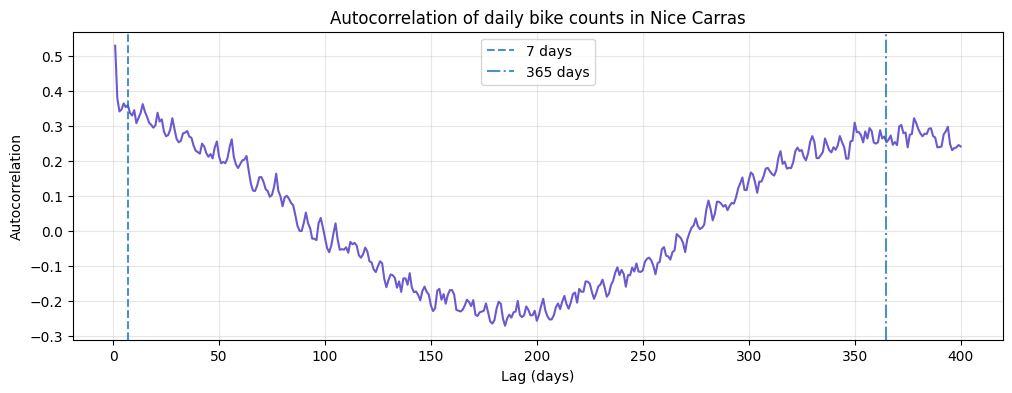

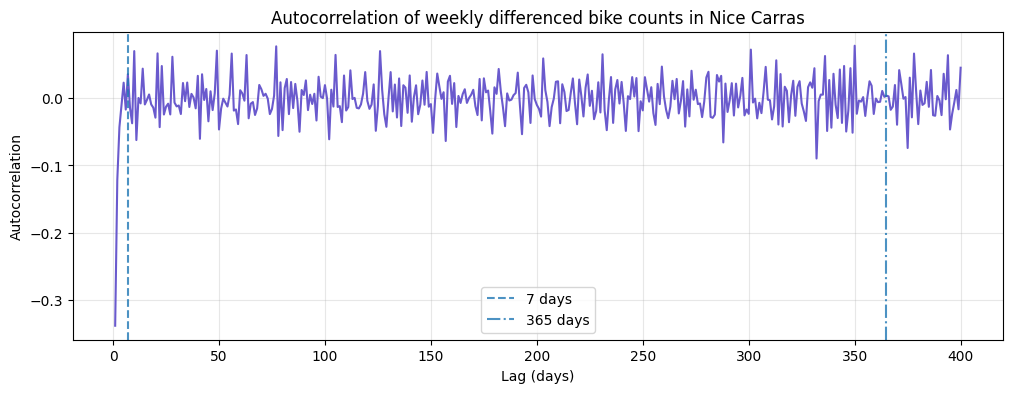

In [8]:
# example usage
plot_acf(data_counters['nice_carras']['count'], max_lag=400, title="Autocorrelation of daily bike counts in Nice Carras")
plot_acf(data_counters['nice_carras']['count'].diff().dropna(), max_lag=400, title="Autocorrelation of weekly differenced bike counts in Nice Carras")

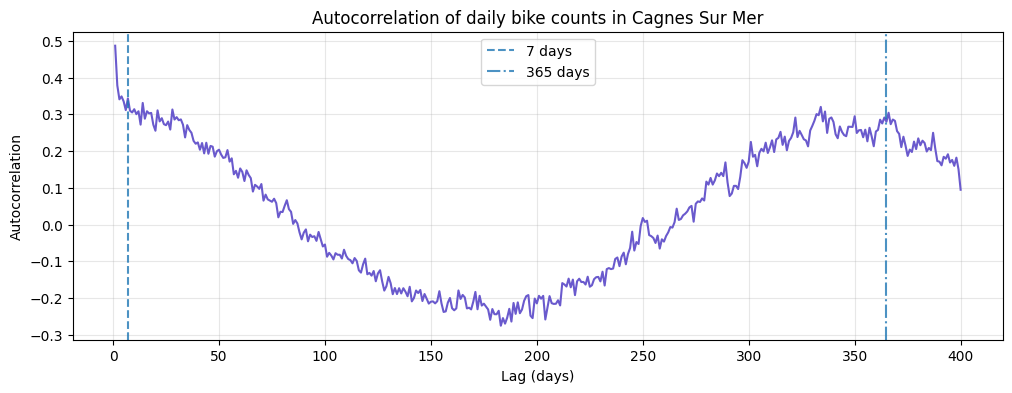

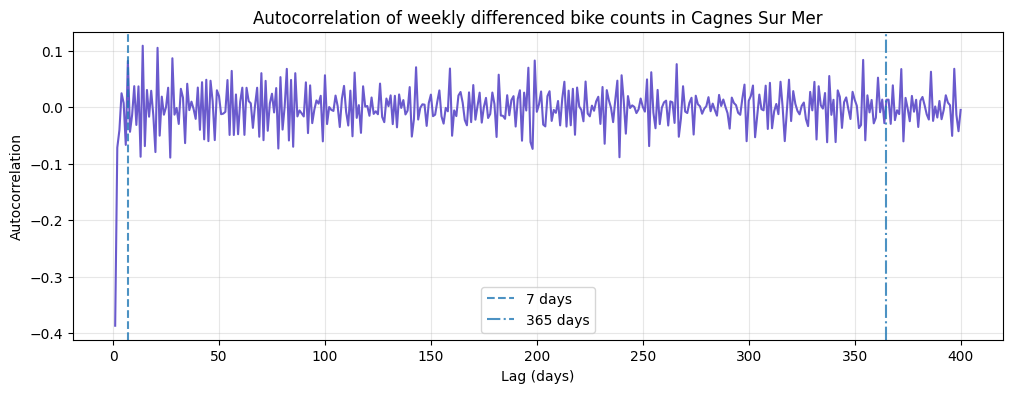

In [9]:
# example usage
plot_acf(data_counters['cagnes_sur_mer']['count'], max_lag=400, title="Autocorrelation of daily bike counts in Cagnes Sur Mer")
plot_acf(data_counters['cagnes_sur_mer']['count'].diff().dropna(), max_lag=400, title="Autocorrelation of weekly differenced bike counts in Cagnes Sur Mer")

## Weekday effect

Representing the bike counts as box plots for each day of the week and each counter shows, indeed, a more obvious pattern in Paris.

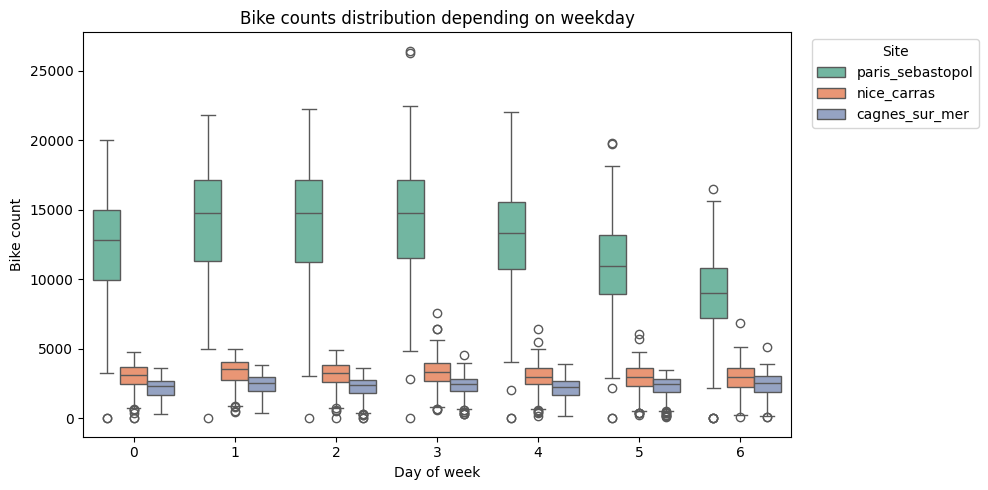

In [10]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plot_data = data_all_counters.reset_index()
plot_data["weekday"] = data_all_counters.index.day_of_week

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=plot_data,
    x="weekday",
    y="count",
    hue="counter",
    palette="Set2",
)
plt.title("Bike counts distribution depending on weekday")
plt.xlabel("Day of week")
plt.ylabel("Bike count")
plt.legend(title="Site", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

As the frequentation of each site can be very different, and the counts display a few outliers, a normalized version of the bike counts is used below, by scaling the count by the 95th percentile of the counts for each site.

In [11]:
data_all_counters.groupby("counter")["count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
counter,,,,,,,,,,,
cagnes_sur_mer,1611.0,2281.612663,778.036578,12.0,1159.0,1832.00,2421.0,2830.5,3159.0,3321.50,5145.0
nice_carras,1862.0,3073.103115,1004.175812,6.0,1671.5,2493.75,3176.0,3781.5,4232.9,4476.75,7585.0
paris_sebastopol,1866.0,12636.016613,4148.928968,0.0,7388.5,9761.00,12642.5,15630.0,17995.5,19353.50,26443.0


In [12]:
q95_by_counter = data_all_counters.groupby("counter")["count"].transform(lambda s: s.quantile(0.95))
data_all_counters["normalized_count"] = data_all_counters["count"] / q95_by_counter
data_all_counters[["count", "normalized_count", "counter"]].head()

,count,normalized_count,counter
date,,,
2021-01-01,166.0,0.037080,nice_carras
2021-01-01,2037.0,0.105252,paris_sebastopol
2021-01-02,349.0,0.077958,nice_carras
2021-01-02,3987.0,0.206009,paris_sebastopol
2021-01-03,3306.0,0.170822,paris_sebastopol


The plot below represents the daily counts distribution for each counter, scaled by the 95% quantile of each counter's dataset.

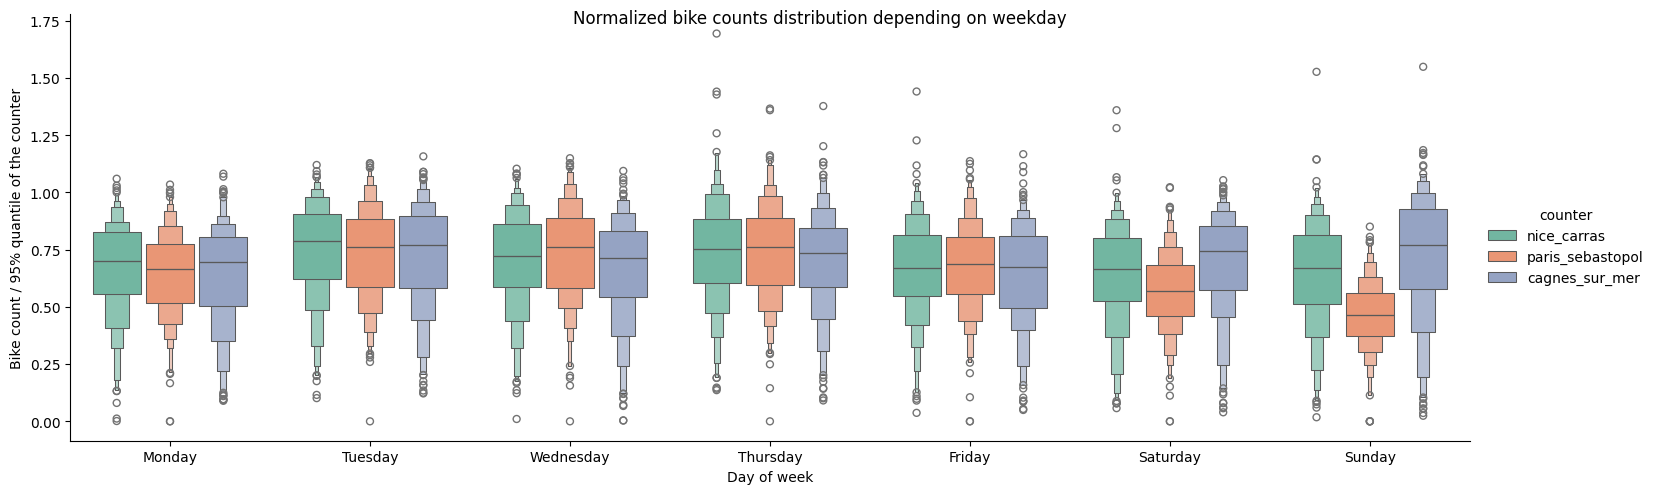

In [43]:
plot_data = data_all_counters.reset_index()
plot_data["weekday"] = data_all_counters.index.day_of_week
plot_data["day_name"] = pd.Categorical(
    plot_data["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="day_name",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=5,
    aspect=3,
)
boxen.fig.suptitle("Normalized bike counts distribution depending on weekday")
boxen.set_xlabels("Day of week")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

In the plot above, one can guess some weekly patterns and their differences or common points between counters. 

Splitting the plots by counter below gives a better insight of the pattern for each counter.

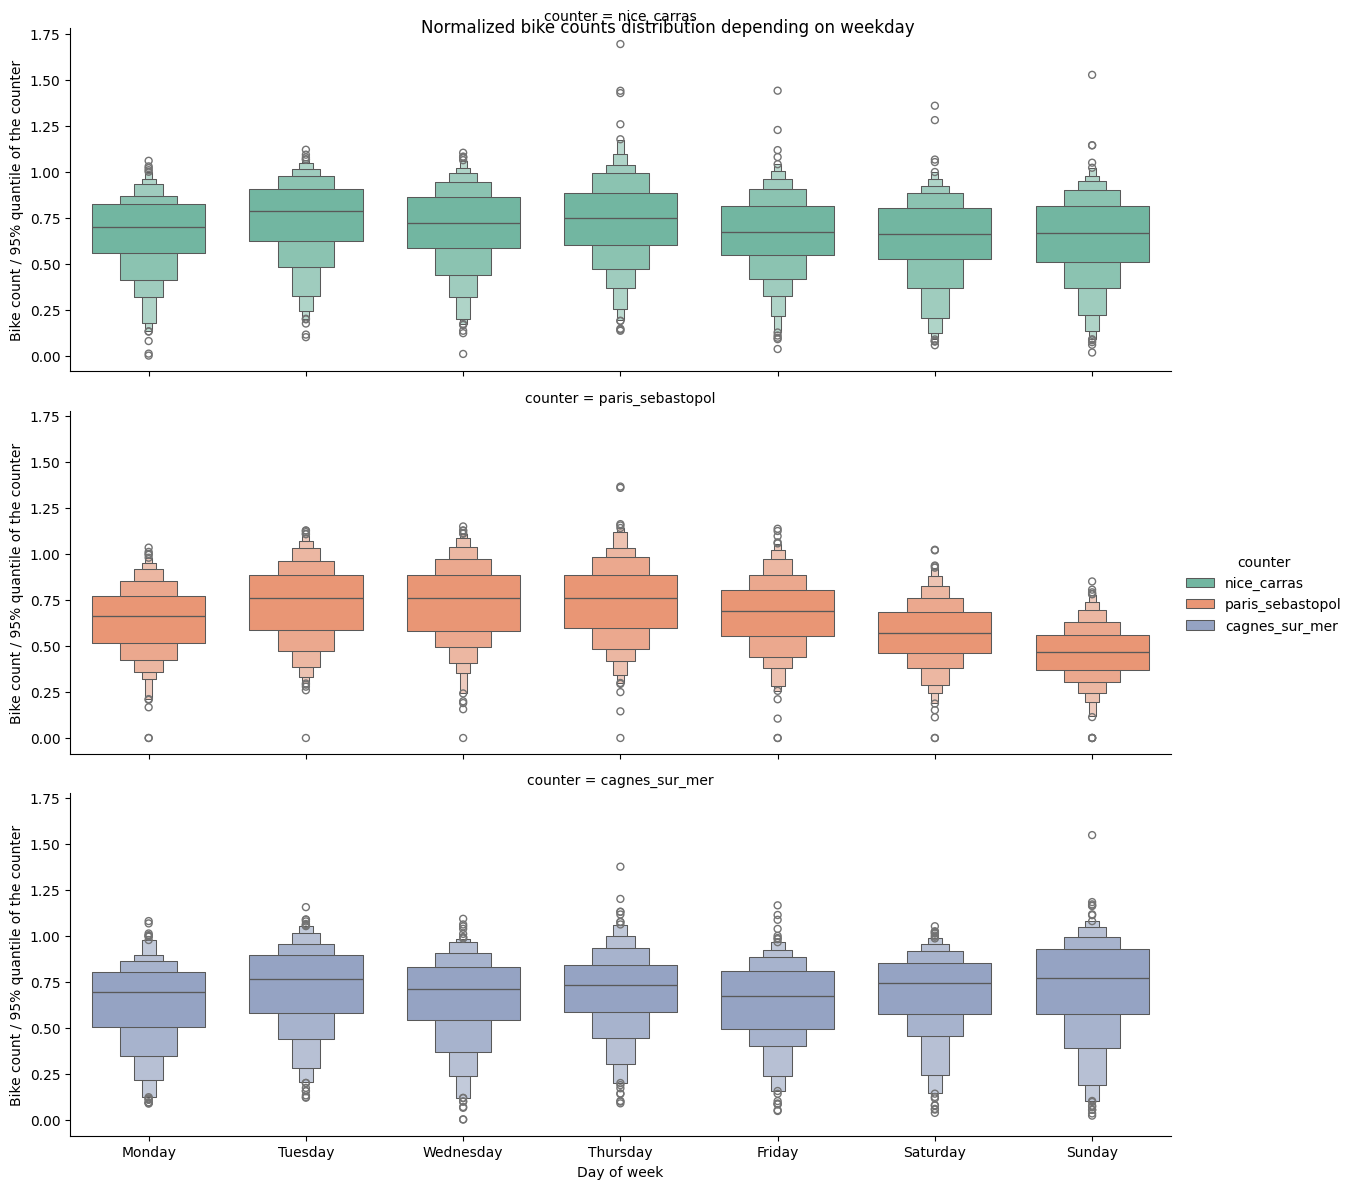

In [ ]:
boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="day_name",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=4,
    aspect=3,
    row="counter",
)
boxen.fig.suptitle("Normalized bike counts distribution depending on weeakday")
boxen.set_xlabels("Day of week")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

It's interesting to see that daily patterns seem to exist and show some similarities from Monday to Friday for all counters.

However, the weekends seem to have different patterns depending on the counter, how was guessed in the very first dataviz when retrieving the data : 
- In Paris Sebastopol, well-known to be mainly used by commuters, weekends are much quieter.
- In Cagnes-sur-Mer and Nice, where the seaside is widely used by commuters, but also by leisure riders, the difference is much less obvious.

Examinating the hourly profiles depending on the day and site could give more insight about the kind of users in each case, but unfortunately, this data is not available on the Eco Counter website.

The effect of weekday could be investigated in a more quantitative manner, and a simple look at the descriptive statistics for each day and counter already provides another point of view, as illustrated below.

Using ANOVA or any related method adapted to the distribution of the data, with the right post-hoc analysis would help figuring out more accurately the patterns, but this is not yet the goal of this notebook, which is rather focused on getting a first insight of the parameters of interest to compare two periods or predict a future count.

In [ ]:
plot_data.groupby(["counter", "day_name"])["normalized_count"].describe()

/tmp/ipykernel_8020/4266291487.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby(["counter", "day_name"])["normalized_count"].describe()


count      mean       std       min       25%  \
counter          day_name                                                   
cagnes_sur_mer   Monday     231.0  0.643401  0.223652  0.089719  0.503538   
                 Tuesday    230.0  0.723121  0.229239  0.121933  0.582117   
                 Wednesday  231.0  0.666458  0.232670  0.003613  0.544633   
                 Thursday   231.0  0.706932  0.222487  0.091224  0.587686   
                 Friday     230.0  0.644531  0.221686  0.049676  0.496011   
                 Saturday   229.0  0.694266  0.220784  0.039440  0.575342   
                 Sunday     229.0  0.730159  0.271569  0.024387  0.577751   
nice_carras      Monday     266.0  0.664309  0.209984  0.001340  0.557045   
                 Tuesday    265.0  0.742258  0.218492  0.101413  0.623220   
                 Wednesday  265.0  0.702242  0.217145  0.010275  0.585469   
                 Thursday   266.0  0.736888  0.229637  0.136260  0.602502   
                 Friday     267.0  0.667080  0.213701  0.037080  0.545485   
                 Saturday   266.0  0.642832  0.224871  0.057631  0.524990   
                 Sunday     267.0  0.650080  0.235235  0.017870  0.510862   
paris_sebastopol Monday     267.0  0.646062  0.185452  0.000000  0.514816   
                 Tuesday    266.0  0.734553  0.207636  0.000000  0.585656   
                 Wednesday  266.0  0.733974  0.211015  0.000000  0.581871   
                 Thursday   266.0  0.743302  0.213829  0.000000  0.597192   
                 Friday     267.0  0.675861  0.197964  0.000000  0.555946   
                 Saturday   267.0  0.571150  0.172594  0.000000  0.461622   
                 Sunday     267.0  0.466388  0.149568  0.000000  0.371638   

                                 50%       75%       max  
counter          day_name                                 
cagnes_sur_mer   Monday     0.698179  0.806262  1.081740  
                 Tuesday    0.768478  0.897561  1.157610  
                 Wednesday  0.713232  0.833358  1.094084  
                 Thursday   0.733705  0.845401  1.377390  
                 Friday     0.673340  0.808144  1.167244  
                 Saturday   0.743941  0.852928  1.053741  
                 Sunday     0.770435  0.927593  1.548999  
nice_carras      Monday     0.698945  0.826492  1.059921  
                 Tuesday    0.788742  0.904674  1.120009  
                 Wednesday  0.723963  0.862903  1.103702  
                 Thursday   0.750991  0.882727  1.694309  
                 Friday     0.670352  0.813425  1.441001  
                 Saturday   0.664210  0.803038  1.359245  
                 Sunday     0.668342  0.812196  1.527001  
paris_sebastopol Monday     0.663808  0.774098  1.034438  
                 Tuesday    0.761749  0.884375  1.127858  
                 Wednesday  0.761516  0.887501  1.149560  
                 Thursday   0.763118  0.886429  1.366316  
                 Friday     0.687834  0.804196  1.137004  
                 Saturday   0.567856  0.682719  1.022967  
                 Sunday     0.465807  0.558969  0.850699

# Vacations, holidays and other calendar exeptions

First, let take a look at the distribution of counts for each counter depending on the fact that a day is a holiday, during vacations or a "normal day".

A categorical variable is defined accordingly. To simplify, a holiday during vacations is just considered as a holiday, neglecting the combination of these features.

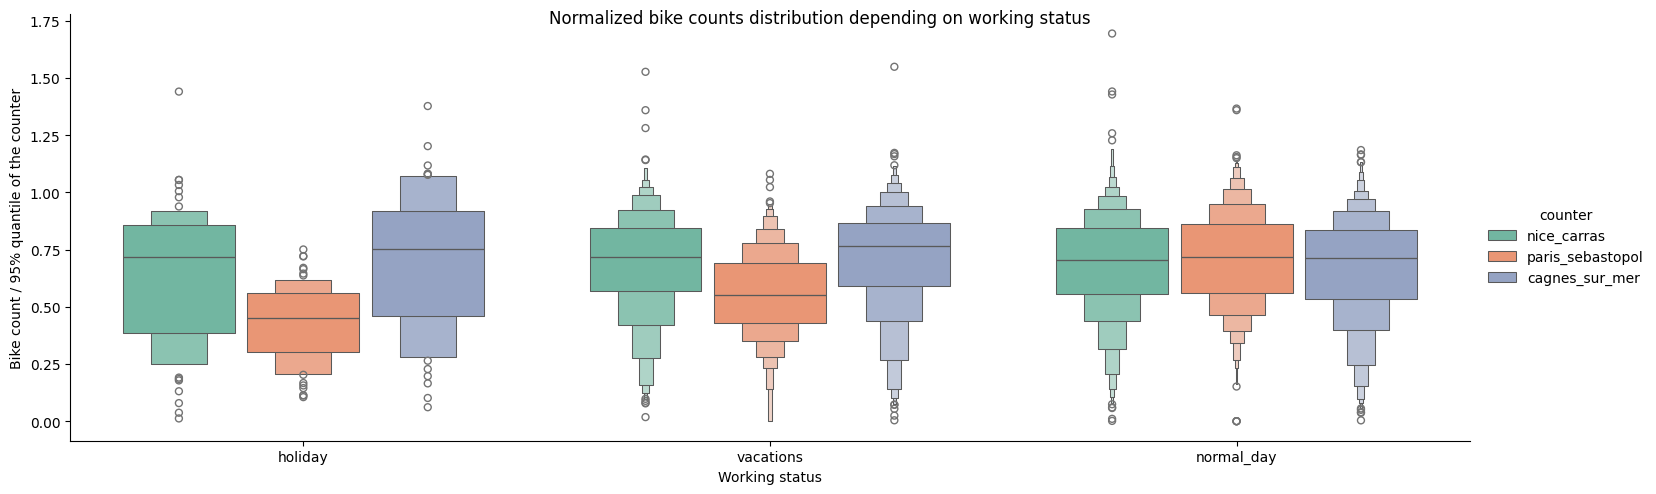

In [44]:
# Define "working status" categorical variable from the "is_holiday" and "is_vacations" boolean columns
working_status_order = ['holiday', 'vacations', 'normal_day']
plot_data["working_status"] = np.select(
    [
        plot_data["is_holiday"],
        plot_data["is_vacations"],
    ],
    [
        "holiday",
        "vacations",
    ],
    default="normal_day"
)
plot_data["working_status"] = pd.Categorical(
    plot_data["working_status"],
    categories=working_status_order,
    ordered=True
)

boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="working_status",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=5,
    aspect=3,
)
boxen.fig.suptitle("Normalized bike counts distribution depending on working status")
boxen.set_xlabels("Working status")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

While a quantitative analysis would be needed to be more accurate, the plot above gives a good insight of what happens at these three locations, with the light of the prior knowledge about the nature of the data.
Once again, Paris Sebastopol shows a different pattern than Nice and Cagnes-sur-Mer.

In Paris, holidays and vacations seem to have a clear effect on the median count of cyclists : holidays are less busy than vacations, which are less busy than normal days. 

In Nice and Cagnes-sur-Mer (neighbouring counters), the effect on the median value is much less obvious (or inexistent). 
However, one can see that the **dispertion** of the counts for these counters during holidays is much higher.



In [45]:
plot_data.groupby(["counter", "working_status"])["normalized_count"].describe()

/tmp/ipykernel_8020/1266729444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby(["counter", "working_status"])["normalized_count"].describe()


count      mean       std       min  \
counter          working_status                                         
cagnes_sur_mer   holiday           46.0  0.702125  0.324607  0.061117   
                 vacations        535.0  0.713363  0.231882  0.003914   
                 normal_day      1030.0  0.672510  0.229689  0.003613   
nice_carras      holiday           56.0  0.643053  0.303969  0.012062   
                 vacations        586.0  0.687214  0.226372  0.017870   
                 normal_day      1220.0  0.688088  0.219004  0.001340   
paris_sebastopol holiday           56.0  0.432402  0.170911  0.105252   
                 vacations        587.0  0.556102  0.187707  0.000000   
                 normal_day      1223.0  0.709466  0.204932  0.000000   

                                      25%       50%       75%       max  
counter          working_status                                          
cagnes_sur_mer   holiday         0.457700  0.754328  0.920217  1.377390  
                 vacations       0.591299  0.766220  0.864369  1.548999  
                 normal_day      0.535150  0.711275  0.835842  1.185007  
nice_carras      holiday         0.387111  0.719719  0.855587  1.440554  
                 vacations       0.569833  0.716368  0.846373  1.527001  
                 normal_day      0.554643  0.705311  0.843581  1.694309  
paris_sebastopol holiday         0.301095  0.450203  0.561836  0.750510  
                 vacations       0.430026  0.549358  0.690883  1.081200  
                 normal_day      0.559873  0.719043  0.862350  1.366316

Of course, this catagory is much less represented in the dataset, which could lead to higher variance.

But as the number of samples of holidays are already about 50 in each counter, and Paris and Nice have the same count of holiday samples, other causes deserve investigation.

In particular, it can be suspected that, provided the prior knowledge that leisure rides are more prominent in Nice and Cagnes, the effect of weather may be more important there on holidays.

Quantitative analysis should therefore (obviously) investigate the effect of the interaction between weather and working status.

# Investigating the effect of weather